# What is the best CNN architecture for Fashion MNIST?
In this notebook we will explore the best choices for CNN architecture using the keras library. We will run iterative experiments to find the most accurate and efficient CNN architure for classifying Fashion MNIST, a dataset containing 70,000 greyscale images of clothing items.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.utils import to_categorical

keras.utils.set_random_seed(0)
IMG_SIZE = 28  # 28x28 pixel images
NUM_CLASSES = 10  # 10 Classes of objects
CHANNELS = 1  # Greyscale single channel images

train = pd.read_csv("/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_train.csv")
test = pd.read_csv("/kaggle/input/datasets/zalando-research/fashionmnist/fashion-mnist_test.csv")

y_train = train["label"]
X_train = train.drop(labels=["label"], axis=1)
y_test = test["label"]
X_test = test.drop(labels=["label"], axis=1)

X_train = X_train.to_numpy().reshape(-1, IMG_SIZE, IMG_SIZE, CHANNELS)
X_test = X_test.to_numpy().reshape(-1, IMG_SIZE, IMG_SIZE, CHANNELS)

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train, num_classes=NUM_CLASSES)

def lr_decay(epoch):
    return 1e-3 * (0.95 ** epoch)

annealer = callbacks.LearningRateScheduler(lr_decay, verbose=0)
styles = [':', '-.', '--', '-', ':', '-.', '--', '-', ':', '-.', '--', '-']

# Notation in this Kaggle kernel
Throughout this kernel, we'll use the following notation:
 * **24C5** means a convolution layer with 24 feature maps using a 5x5 filter and stride 1
 * **24C5S2** means a convolution layer with 24 feature maps using a 5x5 filter and stride 2 
 * **P2** means max pooling using 2x2 filter and stride 2
 * **256** means fully connected dense layer with 256 units

# 1. How many convolution-subsambling pairs?
First question, how many pairs of convolution-subsampling should we use? For example, our network could have 1, 2, or 3:
 * 784 - **[24C5-P2]** - 256 - 10
 * 784 - **[24C5-P2] - [48C5-P2]** - 256 - 10
 * 784 - **[24C5-P2] - [48C5-P2] - [64C5-P2]** - 256 - 10  
   
It is typical to increase the number of feature maps for each subsequent pair as we have done here.

# Experiment 1
Let's see whether one, two, or three pairs is best. We are not doing four pairs since the image will be reduced too small before then. The input image is 28x28. After one pair, it's 14x14. After two, it's 7x7. After three it's 4x4. It doesn't make sense to do a fourth convolution.

In [2]:
# BUILD CONVOLUTIONAL NEURAL NETWORKS
nets = 3
models = []

for j in range(nets):
    model = keras.Sequential()
    model.add(layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS)))
    model.add(layers.Conv2D(24, kernel_size=5, padding='same', activation='relu'))
    model.add(layers.MaxPooling2D())
    
    if j > 0:
        model.add(layers.Conv2D(48, kernel_size=5, padding='same', activation='relu'))
        model.add(layers.MaxPooling2D())
        
    if j > 1:
        model.add(layers.Conv2D(64, kernel_size=5, padding='same', activation='relu'))
        model.add(layers.MaxPooling2D(padding='same'))
        
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    models.append(model)

I0000 00:00:1789659207.468343      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789659207.471448      24 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [3]:
# CREATE VALIDATION SET
X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_train, y_train, test_size=0.333
)

# TRAIN NETWORKS
histories = []
names = ["(C-P)x1", "(C-P)x2", "(C-P)x3"]
epochs = 30

for j in range(nets):
    hist = models[j].fit(
        X_train2, y_train2, 
        batch_size=80, 
        epochs=epochs, 
        validation_data=(X_val2, y_val2), 
        callbacks=[annealer], 
        verbose=0
    )
    histories.append(hist)
    
    max_train_acc = max(hist.history['accuracy'])
    max_val_acc = max(hist.history['val_accuracy'])
    
    print(f"CNN {names[j]}: Epochs={epochs}, Train accuracy={max_train_acc:.5f}, Validation accuracy={max_val_acc:.5f}")

I0000 00:00:1789659212.785993      72 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


CNN (C-P)x1: Epochs=30, Train accuracy=0.99913, Validation accuracy=0.91181
CNN (C-P)x2: Epochs=30, Train accuracy=0.99915, Validation accuracy=0.91562
CNN (C-P)x3: Epochs=30, Train accuracy=0.99878, Validation accuracy=0.91456


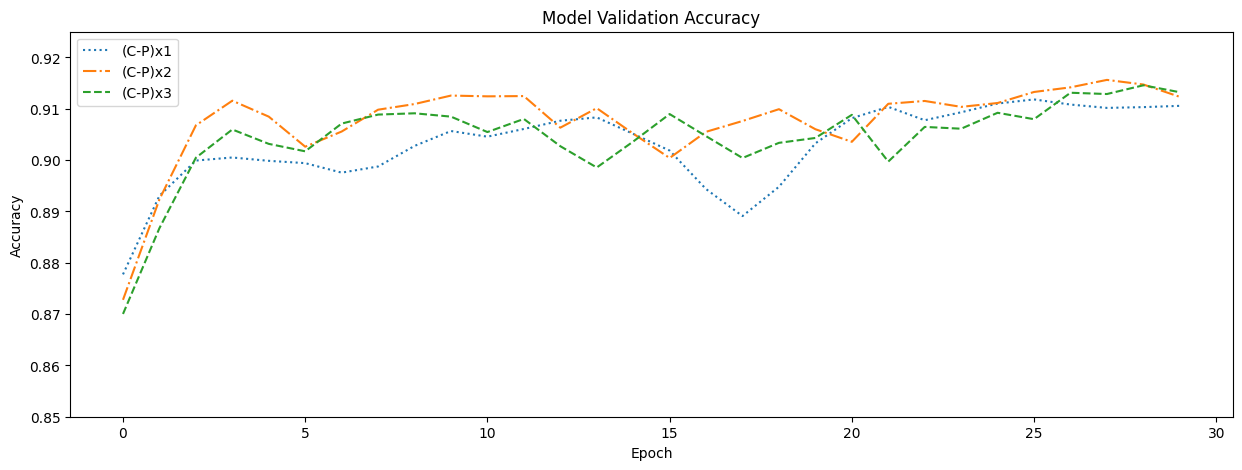

In [4]:
# PLOT ACCURACIES
fig, ax = plt.subplots(figsize=(15, 5))

for j in range(nets):
    ax.plot(
        histories[j].history['val_accuracy'], 
        linestyle=styles[j], 
        label=names[j]
    )

ax.set_title('Model Validation Accuracy')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylim([0.85, 0.925])
ax.legend(loc='upper left')

plt.show()

## Summary
From the above experiment, it seems that 2 pairs of convolution-subsambling has better convergence speed and stability than 1 or 3 pairs so let's use 2.

# 2. How many feature maps?
In the previous experiement, we decided that two pairs is sufficient. How many feature maps should we include? For example, we could do
 * 784 - [**8**C5-P2] - [**16**C5-P2] - 256 - 10
 * 784 - [**16**C5-P2] - [**32**C5-P2] - 256 - 10
 * 784 - [**24**C5-P2] - [**48**C5-P2] - 256 - 10
 * 784 - [**32**C5-P2] - [**64**C5-P2] - 256 - 10
 * 784 - [**40**C5-P2] - [**80**C5-P2] - 256 - 10  
 * 784 - [**48**C5-P2] - [**96**C5-P2] - 256 - 10  

# Experiment 2

In [5]:
# BUILD CONVOLUTIONAL NEURAL NETWORKS
nets = 6
models = []

for j in range(nets):
    model = keras.Sequential()
    
    model.add(layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS)))
    
    model.add(layers.Conv2D(j * 8 + 8, kernel_size=5, activation='relu'))
    model.add(layers.MaxPooling2D())
    
    model.add(layers.Conv2D(j * 16 + 16, kernel_size=5, activation='relu'))
    model.add(layers.MaxPooling2D())
    
    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    
    models.append(model)

In [6]:
# CREATE VALIDATION SET
X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_train, y_train, test_size=0.333
)

# TRAIN NETWORKS
histories = []
names = ["8 maps", "16 maps", "24 maps", "32 maps", "40 maps", "48 maps"]
epochs = 30

for j in range(nets):
    hist = models[j].fit(
        X_train2, y_train2, 
        batch_size=80, 
        epochs=epochs, 
        validation_data=(X_val2, y_val2), 
        callbacks=[annealer], 
        verbose=0
    )
    histories.append(hist)
    
    max_train_acc = max(hist.history['accuracy'])
    max_val_acc = max(hist.history['val_accuracy'])
    
    print(f"CNN {names[j]}: Epochs={epochs}, Train accuracy={max_train_acc:.5f}, Validation accuracy={max_val_acc:.5f}")

CNN 8 maps: Epochs=30, Train accuracy=0.95615, Validation accuracy=0.89830
CNN 16 maps: Epochs=30, Train accuracy=0.98378, Validation accuracy=0.90856
CNN 24 maps: Epochs=30, Train accuracy=0.99398, Validation accuracy=0.90811
CNN 32 maps: Epochs=30, Train accuracy=0.99758, Validation accuracy=0.90996
CNN 40 maps: Epochs=30, Train accuracy=0.99820, Validation accuracy=0.91056
CNN 48 maps: Epochs=30, Train accuracy=0.99895, Validation accuracy=0.91592


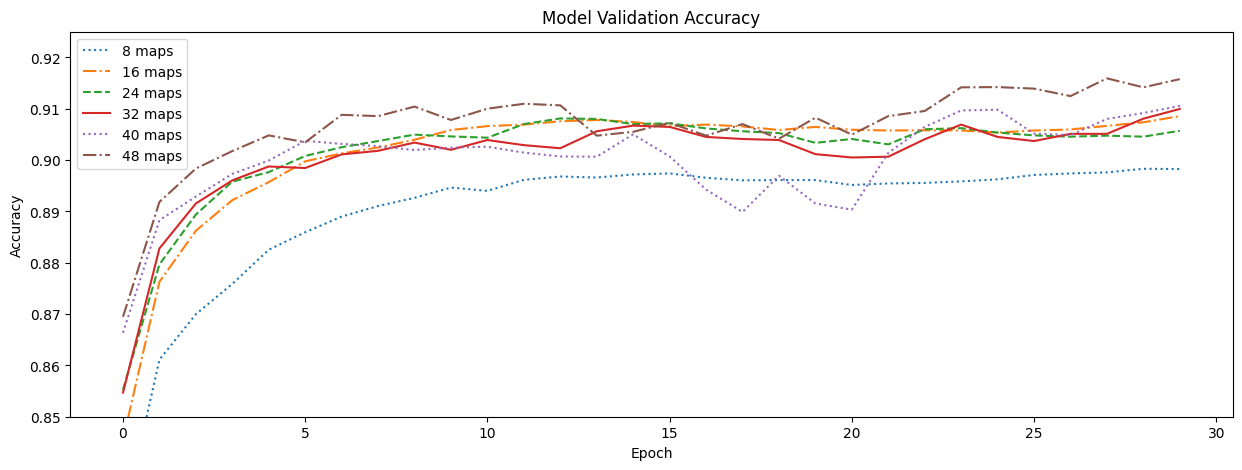

In [7]:
# PLOT ACCURACIES
fig, ax = plt.subplots(figsize=(15, 5))

for j in range(nets):
    ax.plot(
        histories[j].history['val_accuracy'], 
        linestyle=styles[j], 
        label=names[j]
    )

ax.set_title('Model Validation Accuracy')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylim([0.85, 0.925])
ax.legend(loc='upper left')

plt.show()

## Summary
From the above experiement, it appears that 16 maps in the first convolutional layer and 32 maps in the second convolutional layer is the best balance of complexity and stability. Architectures with more maps only perform slightly better and are not worth the additonal computation cost.

# 3. How large a dense layer?
In our previous experiment, we decided on 32 and 64 maps in our convolutional layers. How many dense units should we use? For example we could use
 * 784 - [16C5-P2] - [32C5-P2] - **16** - 10
 * 784 - [16C5-P2] - [32C5-P2] - **32** - 10
 * 784 - [16C5-P2] - [32C5-P2] - **64** - 10
 * 784 - [16C5-P2] - [32C5-P2] - **128** -10
 * 784 - [16C5-P2] - [32C5-P2] - **256** - 10
 * 784 - [16C5-P2] - [32C5-P2] - **512** -10
 * 784 - [16C5-P2] - [32C5-P2] - **1024** - 10
 * 784 - [16C5-P2] - [32C5-P2] - **2048** - 10

# Experiment 3

In [8]:
# BUILD CONVOLUTIONAL NEURAL NETWORKS
nets = 8
models = []

for j in range(nets):
    model = keras.Sequential()
    
    model.add(layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS)))
    
    model.add(layers.Conv2D(16, kernel_size=5, activation='relu'))
    model.add(layers.MaxPooling2D())
    model.add(layers.Conv2D(32, kernel_size=5, activation='relu'))
    model.add(layers.MaxPooling2D())
    
    model.add(layers.Flatten())
    model.add(layers.Dense(2**(j + 4), activation='relu'))
        
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    
    models.append(model)

In [9]:
# CREATE VALIDATION SET
X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_train, y_train, test_size=0.333
)

# TRAIN NETWORKS
histories = []
names = ["16N", "32N", "64N", "128N", "256N", "512N", "1024N", "2048N"]
epochs = 30

for j in range(nets):
    hist = models[j].fit(
        X_train2, y_train2, 
        batch_size=80, 
        epochs=epochs, 
        validation_data=(X_val2, y_val2), 
        callbacks=[annealer], 
        verbose=0
    )
    histories.append(hist)
    
    max_train_acc = max(hist.history['accuracy'])
    max_val_acc = max(hist.history['val_accuracy'])
    
    print(f"CNN {names[j]}: Epochs={epochs}, Train accuracy={max_train_acc:.5f}, Validation accuracy={max_val_acc:.5f}")

CNN 16N: Epochs=30, Train accuracy=0.93023, Validation accuracy=0.89895
CNN 32N: Epochs=30, Train accuracy=0.94653, Validation accuracy=0.90425
CNN 64N: Epochs=30, Train accuracy=0.95397, Validation accuracy=0.90330
CNN 128N: Epochs=30, Train accuracy=0.97231, Validation accuracy=0.90891
CNN 256N: Epochs=30, Train accuracy=0.98713, Validation accuracy=0.90225
CNN 512N: Epochs=30, Train accuracy=0.99435, Validation accuracy=0.90435
CNN 1024N: Epochs=30, Train accuracy=0.99710, Validation accuracy=0.90205
CNN 2048N: Epochs=30, Train accuracy=0.99913, Validation accuracy=0.90616


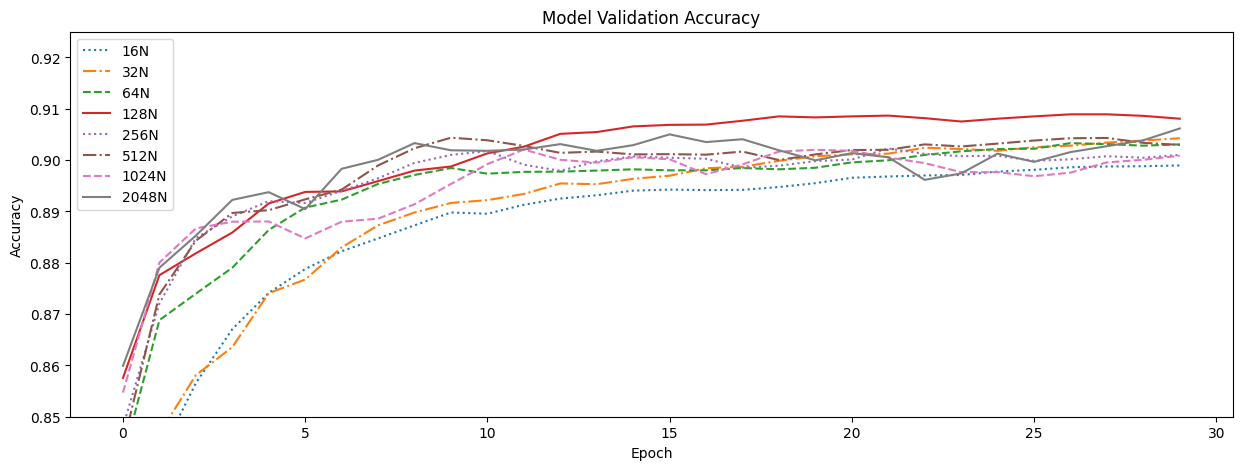

In [10]:
# PLOT ACCURACIES
fig, ax = plt.subplots(figsize=(15, 5))

for j in range(nets):
    ax.plot(
        histories[j].history['val_accuracy'], 
        linestyle=styles[j], 
        label=names[j]
    )

ax.set_title('Model Validation Accuracy')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylim([0.85, 0.925])
ax.legend(loc='upper left')

plt.show()

## Summary
From this experiment, it appears that 128 units is the best option for stability and accuracy.

# 4. How much dropout?
Dropout will prevent our network from overfitting thus helping our network generalize better. How much dropout should we add after each layer?
 * 0%, 10%, 20%, 30%, 40%, 50%, 60%, or 70%

# Experiment 4

In [11]:
# BUILD CONVOLUTIONAL NEURAL NETWORKS
nets = 8
models = []

for j in range(nets):
    model = keras.Sequential()
    
    model.add(layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS)))
    
    model.add(layers.Conv2D(16, kernel_size=5, activation='relu'))
    model.add(layers.MaxPooling2D())
    model.add(layers.Dropout(j*0.1))
    
    model.add(layers.Conv2D(32, kernel_size=5, activation='relu'))
    model.add(layers.MaxPooling2D())
    model.add(layers.Dropout(j*0.1))
    
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(j*0.1))
        
    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    
    models.append(model)

In [12]:
# CREATE VALIDATION SET
X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_train, y_train, test_size=0.333
)

# TRAIN NETWORKS
histories = []
names = ["D=0","D=0.1","D=0.2","D=0.3","D=0.4","D=0.5","D=0.6","D=0.7"]
epochs = 30

for j in range(nets):
    hist = models[j].fit(
        X_train2, y_train2, 
        batch_size=80, 
        epochs=epochs, 
        validation_data=(X_val2, y_val2), 
        callbacks=[annealer], 
        verbose=0
    )
    histories.append(hist)
    
    max_train_acc = max(hist.history['accuracy'])
    max_val_acc = max(hist.history['val_accuracy'])
    
    print(f"CNN {names[j]}: Epochs={epochs}, Train accuracy={max_train_acc:.5f}, Validation accuracy={max_val_acc:.5f}")

CNN D=0: Epochs=30, Train accuracy=0.97404, Validation accuracy=0.90561
CNN D=0.1: Epochs=30, Train accuracy=0.93691, Validation accuracy=0.91356
CNN D=0.2: Epochs=30, Train accuracy=0.91899, Validation accuracy=0.91642
CNN D=0.3: Epochs=30, Train accuracy=0.89818, Validation accuracy=0.90686
CNN D=0.4: Epochs=30, Train accuracy=0.88601, Validation accuracy=0.90445
CNN D=0.5: Epochs=30, Train accuracy=0.86839, Validation accuracy=0.89870
CNN D=0.6: Epochs=30, Train accuracy=0.83906, Validation accuracy=0.88283
CNN D=0.7: Epochs=30, Train accuracy=0.79603, Validation accuracy=0.85350


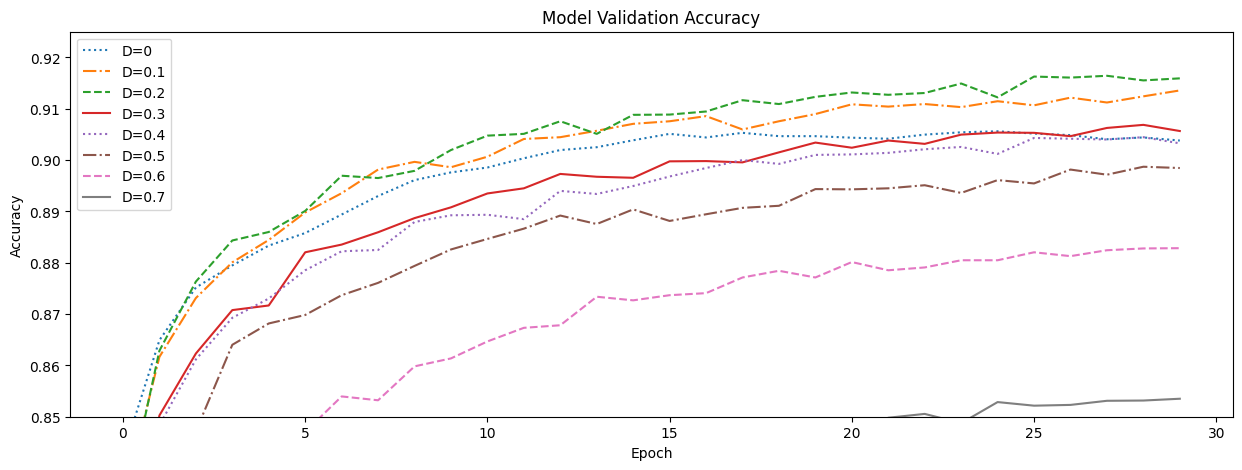

In [13]:
# PLOT ACCURACIES
fig, ax = plt.subplots(figsize=(15, 5))

for j in range(nets):
    ax.plot(
        histories[j].history['val_accuracy'], 
        linestyle=styles[j], 
        label=names[j]
    )

ax.set_title('Model Validation Accuracy')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylim([0.85, 0.925])
ax.legend(loc='upper left')

plt.show()

## Summary
From this experiment, it appears that 20% dropout is the best.

# 5. Advanced features
Instead of using one convolution layer of size 5x5, you can mimic 5x5 by using two consecutive 3x3 layers and it will be more nonlinear. Instead of using a max pooling layer, you can subsample by using a convolution layer with strides=2 and it will be learnable. Lastly, does batch normalization help? And does data augmentation help? Let's test all four of these
 * replace '16C5' with '16C3-16C3'  
 * replace 'P2' with '16C5S2'
 * add batch normalization
 * add data augmentation

In [14]:
# BUILD CONVOLUTIONAL NEURAL NETWORKS
nets = 5
models = []

for j in range(nets):
    model = keras.Sequential()
    
    model.add(layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS)))
    
    # MODEL 0: BASE
    if j == 0:
        model.add(layers.Conv2D(16, kernel_size=5, activation='relu'))
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(0.2))
        
        model.add(layers.Conv2D(32, kernel_size=5, activation='relu'))
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(0.2))
        
        model.add(layers.Flatten())
        model.add(layers.Dense(128, activation='relu'))
        model.add(layers.Dropout(0.2))
        model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

    # MODEL 1: TWO CONSECUTIVE 3x3s
    elif j == 1:
        model.add(layers.Conv2D(16, kernel_size=3, activation='relu'))
        model.add(layers.Conv2D(16, kernel_size=3, activation='relu'))
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(0.2))
        
        model.add(layers.Conv2D(32, kernel_size=3, activation='relu'))
        model.add(layers.Conv2D(32, kernel_size=3, activation='relu'))
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(0.2))
        
        model.add(layers.Flatten())
        model.add(layers.Dense(128, activation='relu'))
        model.add(layers.Dropout(0.2))
        model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

    # MODEL 2: STRIDED CONVOLUTION
    elif j == 2:
        model.add(layers.Conv2D(16, kernel_size=5, activation='relu'))
        model.add(layers.Conv2D(16, kernel_size=5, strides=2, padding='same', activation='relu'))
        model.add(layers.Dropout(0.2))
        
        model.add(layers.Conv2D(32, kernel_size=5, activation='relu'))
        model.add(layers.Conv2D(32, kernel_size=5, strides=2, padding='same', activation='relu'))
        model.add(layers.Dropout(0.2))
        
        model.add(layers.Flatten())
        model.add(layers.Dense(128, activation='relu'))
        model.add(layers.Dropout(0.2))
        model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

    # MODEL 3: ADD BATCH NORMALIZATION
    elif j == 3:
        model.add(layers.Conv2D(16, kernel_size=5, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(0.2))
        
        model.add(layers.Conv2D(32, kernel_size=5, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(0.2))
        
        model.add(layers.Flatten())
        model.add(layers.Dense(128, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(0.2))
        model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
        
    # MODEL 4: BATCH NORMALIZATION + DATA AUGMENTATION
    elif j == 4:
        model.add(layers.RandomRotation(factor=10 / 360))
        model.add(layers.RandomZoom(height_factor=(-0.1, 0.1), width_factor=(-0.1, 0.1)))
        model.add(layers.RandomTranslation(height_factor=0.1, width_factor=0.1))
        
        model.add(layers.Conv2D(16, kernel_size=5, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(0.2))
        
        model.add(layers.Conv2D(32, kernel_size=5, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D())
        model.add(layers.Dropout(0.2))
        
        model.add(layers.Flatten())
        model.add(layers.Dense(128, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(0.2))
        model.add(layers.Dense(NUM_CLASSES, activation='softmax'))
    
    model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    models.append(model)



In [15]:
# CREATE VALIDATION SET
X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_train, y_train, test_size=0.333
)

histories = []
names = ["Base", "16C3-16C3", "16C5S2", "both+BN", "both+BN+DA"]
epochs = 30

for j in range(nets):
    hist = models[j].fit(
        X_train2, y_train2, 
        batch_size=80, 
        epochs=epochs, 
        validation_data=(X_val2, y_val2), 
        callbacks=[annealer], 
        verbose=0
    )
    histories.append(hist)
    
    max_train_acc = max(hist.history['accuracy'])
    max_val_acc = max(hist.history['val_accuracy'])
    print(f"CNN {names[j]}: Epochs={epochs}, Train accuracy={max_train_acc:.5f}, Validation accuracy={max_val_acc:.5f}")

CNN Base: Epochs=30, Train accuracy=0.91954, Validation accuracy=0.91782
CNN 16C3-16C3: Epochs=30, Train accuracy=0.93171, Validation accuracy=0.92337
CNN 16C5S2: Epochs=30, Train accuracy=0.94405, Validation accuracy=0.91777
CNN both+BN: Epochs=30, Train accuracy=0.93561, Validation accuracy=0.92082


E0000 00:00:1789661215.039520      24 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_29_1/dropout_36_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


CNN both+BN+DA: Epochs=30, Train accuracy=0.86522, Validation accuracy=0.89269


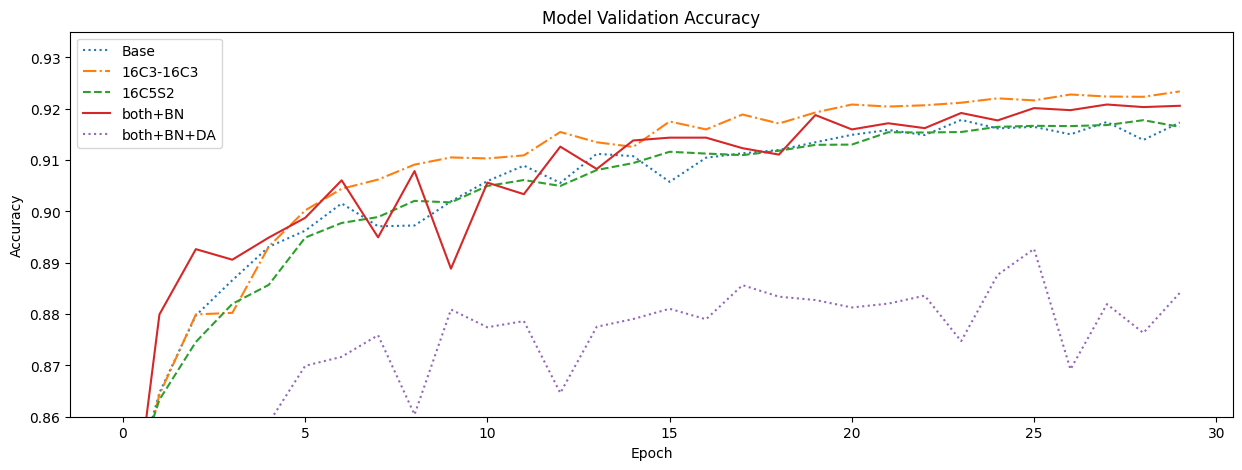

In [16]:
# PLOT ACCURACIES
fig, ax = plt.subplots(figsize=(15, 5))

for j in range(nets):
    ax.plot(
        histories[j].history['val_accuracy'], 
        linestyle=styles[j], 
        label=names[j]
    )

ax.set_title('Model Validation Accuracy')
ax.set_ylabel('Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylim([0.860, 0.935])
ax.legend(loc='upper left')

plt.show()

## Summary
From this experiment, we see that of the four advanced features using two 3x3 layer improves accuracy. Also, batch normalisation seems to help. The first model uses no advanced features. The second uses only the double convolution layer trick. The third uses only the learnable subsambling layer trick. The third model uses only batch normalization. The last model employs batch normalisation plus data augmentation.

# Conclusion
Training convolutional neural networks is a random process. This makes experiments difficult because each time you run the same experiment, you get different results. Therefore, you must run your experiments dozens of times and take an average. This kernel was run dozens of times and it seems that the best CNN architecture for classifying fashion MNIST is 784 - [16C5-P2] - [32C5-P2] - 128 - 10 with 20% dropout. Afterward, more experiments show that replacing '32C5' with '32C3-32C3' improves accuracy. And adding batch normalizaiton improves the CNN. The best CNN found from the experiments here becomes
 *  **784 - [16C3-16C3-P2] - [32C3-32C3-P2] - 128 - 10** 
 * with 20% dropout and batch normalization added

# Predict "test.csv" and submit to Kaggle

In [17]:
# BUILD FINAL MODEL
model = keras.Sequential()
    
model.add(layers.Input(shape=(IMG_SIZE, IMG_SIZE, CHANNELS)))

model.add(layers.Conv2D(16, kernel_size=3, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(16, kernel_size=3, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D())
model.add(layers.Dropout(0.2))

model.add(layers.Conv2D(32, kernel_size=3, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(32, kernel_size=3, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D())
model.add(layers.Dropout(0.2))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.2))
model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [18]:
# CREATE VALIDATION SET
X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_train, y_train, test_size=0.333
)

epochs = 40

hist = model.fit(
    X_train2, y_train2, 
    batch_size=80, 
    epochs=epochs, 
    validation_data=(X_val2, y_val2), 
    callbacks=[annealer], 
    verbose=0
)

    
max_train_acc = max(hist.history['accuracy'])
max_val_acc = max(hist.history['val_accuracy'])
print(f"CNN FINAL: Epochs={epochs}, Train accuracy={max_train_acc:.5f}, Validation accuracy={max_val_acc:.5f}")

CNN FINAL: Epochs=40, Train accuracy=0.95625, Validation accuracy=0.93058


In [19]:
print("Generating predictions on the test set...")
predictions = model.predict(X_test, verbose=0)

y_pred = np.argmax(predictions, axis=1)

test_accuracy = accuracy_score(y_test, y_pred)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Generating predictions on the test set...
Final Test Accuracy: 93.32%

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.89      0.89      1000
           1       0.99      0.99      0.99      1000
           2       0.91      0.90      0.91      1000
           3       0.93      0.95      0.94      1000
           4       0.89      0.91      0.90      1000
           5       0.99      0.97      0.98      1000
           6       0.83      0.80      0.81      1000
           7       0.95      0.97      0.96      1000
           8       0.99      0.99      0.99      1000
           9       0.97      0.96      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000

